I want to lay out in pictures why our SED-based method is viable for identifying broad Na-D white dwarfs, and the easiest way to do that is most likely to plot the spectrum of GaiaJ1644-0449 overlaid with the PanSTARRS bandpasses. Therefore, I need to be combining two different sets of functions in this production that come from two different directories (and the data are in a third directory), so I'll probably need to be switching around directories.

In [1]:
from __future__ import print_function
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp

And I need to import the passband script itself

In [2]:
import plotting_passbands as pp

In [3]:
gaia_dir='/Users/BenKaiser/Desktop/gaia/'

Now I need to do the initial generation of the passband plot to then populate with the spectrum at a later moment and then show... hopefully

In [4]:
#pp.plot_panstarrs_passbands(render_main_plot=False)

So that wasn't supposed to display...

Ok, I edited the script to add a kwarg for whether or not to show the main plot after creating the damn thing.

In [5]:
#plt.show()

In [6]:
#pp.plot_panstarrs_passbands(render_main_plot=True)

Super. Now I have to actually say to plot the damn thing, so that's good. I'll deal with the key and all the other garbage later.

In [7]:
#fig= plt.figure(figsize=(10,5))
#pp.plot_panstarrs_passbands(render_main_plot=False)

Now for the retrieval of the spectra and plotting and stuff. So I'll just follow the example in the other notebooks on how to do this part...

In [8]:
rv_dir='/Users/BenKaiser/Desktop/radial_velocity_calculations/'

In [9]:
print(os.getcwd())

/Users/BenKaiser/Desktop/gaia


In [10]:
os.chdir(rv_dir)
print(os.getcwd())

/Users/BenKaiser/Desktop/radial_velocity_calculations


In [11]:
import spec_plot_tools as spt
import cal_params as cp
import plot_spec as ps
import numpy as np



no file_setting specificied




Ok, so I appear to have successfully loaded libraries from two different locations into the same notebook, which was the biggest hindrance to my previous efforts to produce these plots. Now it should be downhill

In [12]:
target_dir= '/Users/BenKaiser/Desktop/files_for_Dufour/'
M0703_file='ravg_fwctb.GaiaJ1644m0449_20190703_400m2.fits'
M0729_file='ravg_fwctb.GaiaJ1644m0449_20190729_400m1.fits'
M0825_file='ravg_fwctb.GaiaJ1644m0449_20190825_400m2.fits'
model_spec_file='J1644_fit_flambda.dms'

In [13]:
os.chdir(target_dir)

In [14]:
M0703_spec, header, target_noise= spt.retrieve_spec(M0703_file)
M0729_spec, header, target_noise= spt.retrieve_spec(M0729_file)
M0825_spec, header, target_noise= spt.retrieve_spec(M0825_file)

In [15]:
sm_M0703_spec= ps.convolve_spectrum(M0703_spec, header, kernel_type='box', pix_width=3)
sm_M0729_spec= ps.convolve_spectrum(M0729_spec, header, kernel_type='box', pix_width=3)
sm_M0825_spec= ps.convolve_spectrum(M0825_spec, header, kernel_type='box',pix_width=3)
norm_range=[6630, 6690]


sm_M0703_spec= ps.norm_spectrum(sm_M0703_spec, norm_range, show_norm_range=False)
sm_M0729_spec= ps.norm_spectrum(sm_M0729_spec, norm_range, show_norm_range=False)
sm_M0825_spec= ps.norm_spectrum(sm_M0825_spec, norm_range, show_norm_range=False)
sm_M0729_spec[1]=sm_M0729_spec[1]/np.nanmax(sm_M0825_spec[1])
sm_M0825_spec[1]=sm_M0825_spec[1]/np.nanmax(sm_M0825_spec[1])





wavelength-based norm range selected [6630, 6690]





wavelength-based norm range selected [6630, 6690]





wavelength-based norm range selected [6630, 6690]





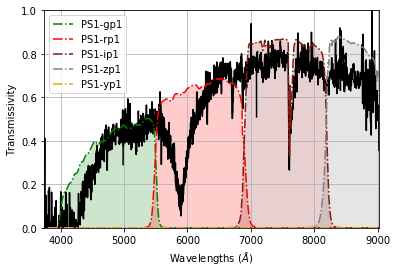

In [16]:
os.chdir(rv_dir)
#plt.rc('font',size=12)
label_pos=3.3
label_off=20
x_pos= 4500
y_pos= 0.92
plt.plot(sm_M0729_spec[0],sm_M0729_spec[1],  color='k')
plt.plot(sm_M0825_spec[0],sm_M0825_spec[1], color='k')
plt.ylabel(r'$f_{\lambda}$ (arbitrary units) and Transmissivity')
plt.xlabel(r'$\lambda(\AA)$')
plt.xlim(np.nanmin(sm_M0729_spec[0]), np.nanmax(sm_M0825_spec[0]))
os.chdir(gaia_dir)
pp.plot_panstarrs_passbands(render_main_plot=True)

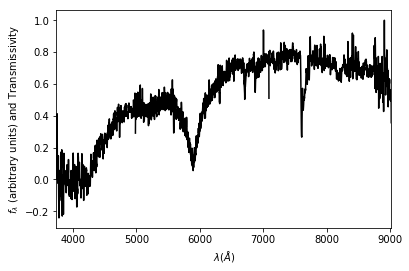

In [17]:
#plt.rc('font',size=12)
label_pos=3.3
label_off=20
x_pos= 4500
y_pos= 0.92
plt.plot(sm_M0729_spec[0],sm_M0729_spec[1],  color='k')
plt.plot(sm_M0825_spec[0],sm_M0825_spec[1], color='k')
plt.ylabel(r'$f_{\lambda}$ (arbitrary units) and Transmissivity')
plt.xlabel(r'$\lambda(\AA)$')
plt.xlim(np.nanmin(sm_M0729_spec[0]), np.nanmax(sm_M0825_spec[0]))
plt.show()




So... what happened to the fill? And more importantly-ish, I can't normalize by just the max value by itself...

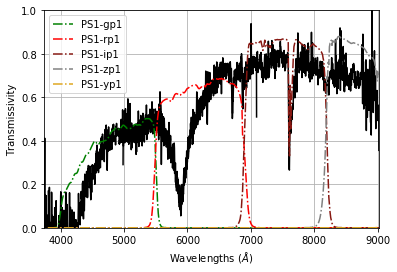

In [18]:
os.chdir(rv_dir)
#plt.rc('font',size=12)
label_pos=3.3
label_off=20
x_pos= 4500
y_pos= 0.92
plt.plot(sm_M0729_spec[0],sm_M0729_spec[1],  color='k')
plt.plot(sm_M0825_spec[0],sm_M0825_spec[1], color='k')
plt.ylabel(r'$f_{\lambda}$ (arbitrary units) and Transmissivity')
plt.xlabel(r'$\lambda(\AA)$')
plt.xlim(np.nanmin(sm_M0729_spec[0]), np.nanmax(sm_M0825_spec[0]))
os.chdir(gaia_dir)
pp.plot_panstarrs_passbands(render_main_plot=True)

So I can't just call that when I'm in a different directory because the script looks up the file assuming that it was summoned in its native location, which is not the case here. So the simplest solution would be to just pair every call of something with a directory change to its location.

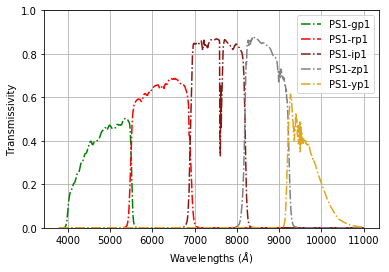

In [19]:
pp.plot_panstarrs_passbands(render_main_plot=True)

So the filling appears to have just broken down fundamentally for no apparent reason...

I wonder if it was me messing with the plot.rc stuff?

Oh, the fill is created in a separate "ax" object or whatever, so whenever I attempted to plot it was putting it back on that same old object presumably... that's a bit weird..